In [11]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
import pyreadr

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
# C. Elegans
path = "data"
suffix = "packer2019.h5ad"
filename = os.path.join(path, suffix)
adata = sc.read_h5ad(filename)

In [14]:
adata = adata[adata.obs['time_point'].isin(['300_minutes', '400_minutes', '500_minutes'])]
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:170: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)


In [16]:
adata.write_h5ad("data/celegans.h5ad")

In [3]:
adata = import_zebra_data()

In [4]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [5]:
# sc.pp.calculate_qc_metrics(
#     adata, inplace=True, log1p=True
# )

In [6]:
# sc.pl.violin(
#     adata,
#     ["n_genes_by_counts", "total_counts"],
#     jitter=0.4,
#     multi_panel=True,
# )

In [7]:
adata.var["gene_short_name"] = adata.var["gene_short_name"].astype(str)
adata.var_names = adata.var["gene_short_name"].values
adata.var_names_make_unique()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [9]:
adata_raw = adata.copy()

In [10]:
adata = adata_raw.copy()

In [11]:
#TODOS:
#Try median normalization?  Different normalization scheme?
#Counts per million instead of log1p
#Subset to specific tissues?  Maybe the perturbations aren't relevant in most tissue types

In [12]:
# Apparently this is sparsity friendly where normalize_total pruning isn't
# gene_sums = adata.X.sum(axis=0).A1
# threshold = np.percentile(gene_sums, 99)
# highly_expressed_mask = gene_sums < threshold
# adata = adata[:, highly_expressed_mask]

In [13]:
adata = adata[adata.obs['gene_target'] == 'ctrl-inj']

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:698: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


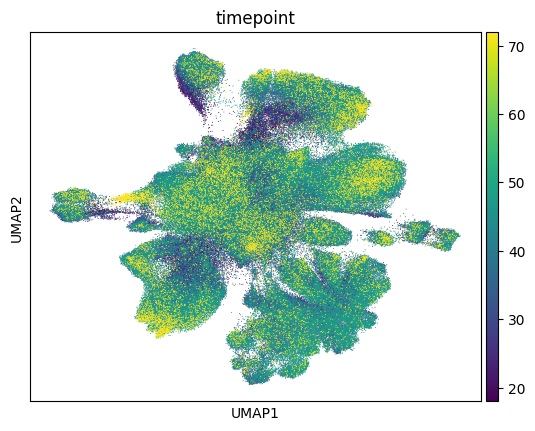

In [15]:
sc.pl.umap(
    adata,
    color="timepoint",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

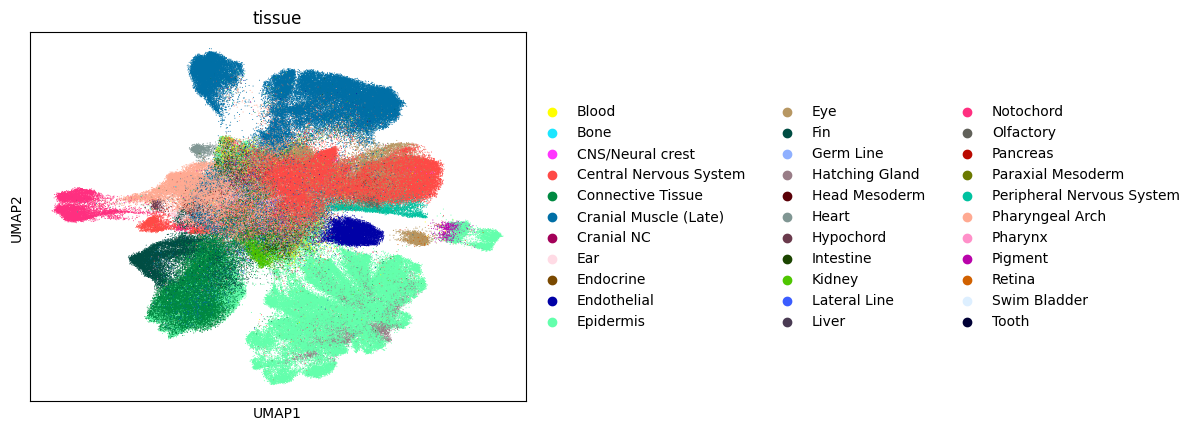

In [16]:
sc.pl.umap(
    adata,
    color="tissue",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [17]:
adata = adata_raw.copy()

In [18]:
adata = adata[adata.obs['timepoint'] == 24]

In [19]:
# targets = list(adata_raw.obs['gene_target'].unique())
# perturbed_bool = adata.var['gene_short_name'].isin(targets)
# perturbed = adata.var['gene_short_name'][perturbed_bool]
# sc.pl.violin(adata, keys=list(perturbed), scale="width", stripplot=False) #groupby?

In [20]:
####################################################################################

In [21]:
adata.obs["gene_target"].value_counts()

gene_target
ctrl-inj        63433
hand2           23841
zc4h2           23520
tbx1            22590
tbx16           19389
tbx16-msgn1     19384
tbx16-tbx16l    18574
smo             18442
noto            17565
epha4a          15665
egr2b           15471
noto-mut        14784
mafba-mut       14446
hoxb1a          13823
cdx4            12983
mafba           11755
cdx4-cdx1a       9313
tbxta            8686
ctrl-mafba       8323
ctrl-noto        4820
wnt3a-wnt8       4738
ctrl-tbx16       4184
tbx16-mut        3600
Name: count, dtype: int64

In [22]:
list(adata.obs['tissue'].unique())

['Epidermis',
 'Eye',
 'Ear',
 'Central Nervous System',
 'Pharyngeal Arch',
 'Fin',
 'Connective Tissue',
 'Cranial Muscle (Late)',
 'Paraxial Mesoderm',
 'Notochord',
 'Kidney',
 'Olfactory',
 'Endothelial',
 'Hatching Gland',
 'Lateral Line',
 'Intestine',
 'Cranial NC',
 'Peripheral Nervous System',
 'Blood',
 'Pigment',
 'Hypochord',
 'Endocrine',
 'Heart',
 'Germ Line',
 'Pharynx',
 'Pancreas',
 'Head Mesoderm',
 'Bone',
 'Retina',
 'CNS/Neural crest',
 nan,
 'Liver',
 'Swim Bladder']

In [23]:
adata.obs.keys()


Index(['cell', 'Size_Factor', 'n.umi', 'perc_mitochondrial_umis', 'timepoint',
       'hash_umis', 'top_to_second_best_ratio', 'expt', 'cell_type_sub',
       'cell_type_broad', 'tissue', 'germ_layer', 'log.n.umi',
       'num_genes_expressed', 'umap3d_1', 'umap3d_2', 'umap3d_3',
       'major_group', 'gene_target', 'mean_nn_time', 'subumap3d_1',
       'subumap3d_2', 'subumap3d_3', 'embryo', 'temp', 'n_genes'],
      dtype='object')

In [24]:
list(adata.obs['cell_type_broad'].unique())

['periderm',
 'eye, optic cup',
 'support cells/otic vesicle',
 'neural progenitor (MHB)',
 'head mesenchyme/PA cartilage',
 'pectoral fin bud (osteoblast+)',
 'connective tissue-meninges-dermal FB',
 'retinal neuron',
 'neural progenitor (hindbrain)',
 'fast-committed myocyte',
 'fin mesenchyme',
 'mature slow muscle',
 'mesodermal progenitor cells (contains PSM)',
 'neurons (gabaergic, glutamatergic; contains Purkinje)',
 'head mesenchyme (maybe ventral, hand2+)',
 'mature fast muscle',
 'notochord',
 'head/eye connective tissue',
 'pharyngeal arch (NC-derived)',
 'differentiating neuron (hindbrain)',
 'pronephros proximal tubule',
 'olfactory vesicle/bulb',
 'anterior migratory muscle',
 'KA neuron',
 'neural progenitor (telencephalon/diencephalon)',
 'endothelium (dorsal aorta)',
 'endothelium (vein + early artery)',
 'neural progenitor (hindbrain R7/8)',
 'hatching gland',
 'floor plate',
 'posterior lateral line primordium',
 'intestine',
 'neural tube-like connective tissue (+ t

In [ ]:
# adata_ctrl = adata[(adata.obs['gene_target']=='mafba')]
# adata_ctrl.obs['embryo'].value_counts()

In [ ]:
# sc.pp.highly_variable_genes(adata_ctrl, n_top_genes=2000)
# sc.tl.pca(adata_ctrl)
# sc.pp.neighbors(adata_ctrl)
# sc.tl.umap(adata_ctrl)

In [ ]:
# sc.pl.umap(
#     adata_ctrl,
#     color="embryo",
#     # Setting a smaller point size to get prevent overlap
#     size=2,
# )

In [ ]:
# sc.pl.umap(
#     adata_ctrl,
#     color="tissue",
#     # Setting a smaller point size to get prevent overlap
#     size=2,
# )

In [25]:
gene_target = "tbx16-tbx16l"
keys = ['tbx16', 'tbx16l']
tissues = ['Head Mesoderm', 'Paraxial Mesoderm']
cell_type_broads = ['mesodermal progenitor cells (contains PSM)', 
                    'posterior spinal cord progenitors',
                   'mature fast muscle']
tissue_bool = adata.obs['tissue'].isin(tissues)
cell_bool = adata.obs['cell_type_broad'].isin(cell_type_broads)

In [26]:
adata_ctrl = adata[(adata.obs['gene_target']=='ctrl-inj') & (tissue_bool)]
adata_per = adata[(adata.obs['gene_target']==gene_target) & (tissue_bool)]

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to m

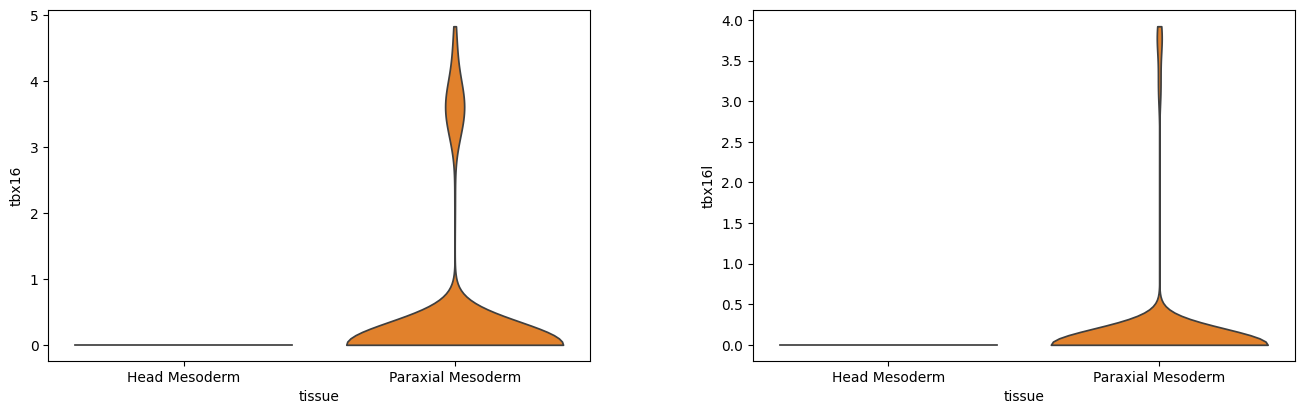

In [27]:
sc.pl.violin(adata_ctrl, keys=keys, groupby="tissue", scale="width", stripplot=False, legend=False)

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to m

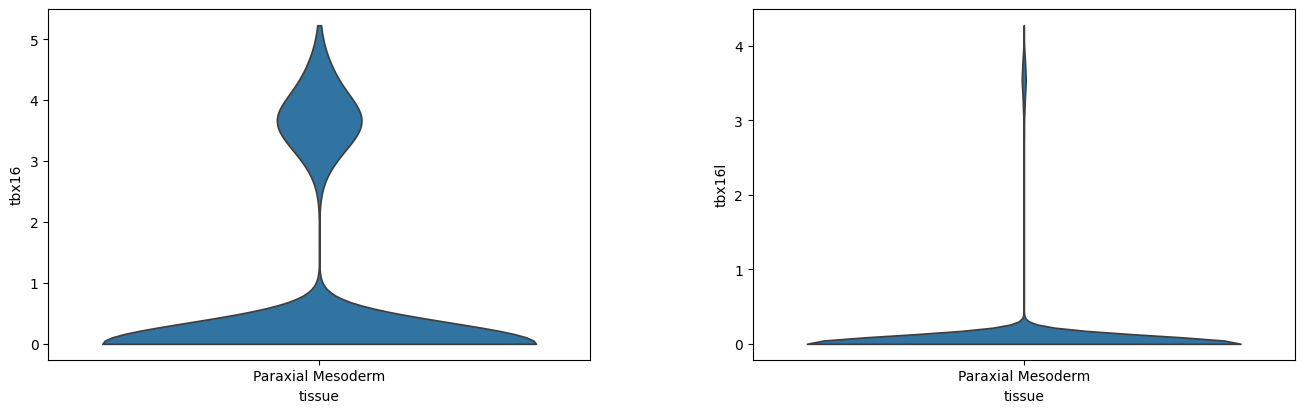

In [28]:
sc.pl.violin(adata_per, keys=keys, groupby="tissue", scale="width", stripplot=False, legend=False)  

In [30]:
adata_ctrl = adata[(adata.obs['gene_target']=='ctrl-inj') & (cell_bool)]
adata_per = adata[(adata.obs['gene_target']==gene_target) & (cell_bool)]

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to m

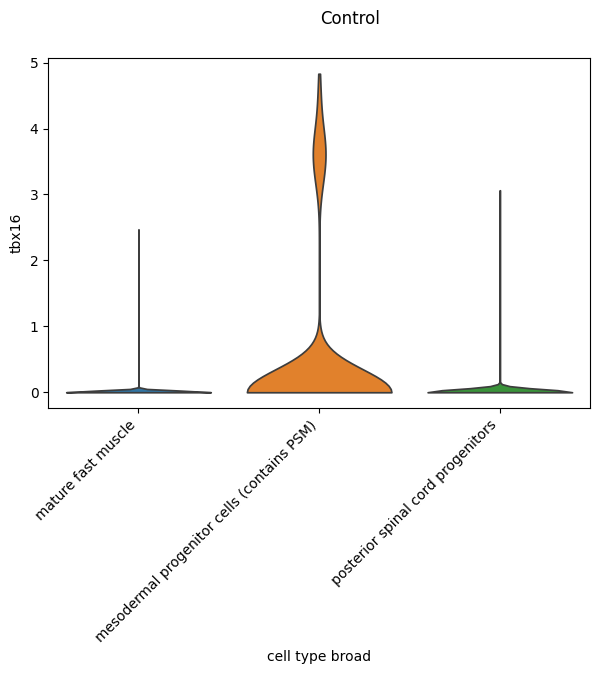

In [31]:
sc.pl.violin(adata_ctrl, keys=keys[0], groupby="cell_type_broad", scale="width", stripplot=False, legend=False, show=False)
fig = plt.gcf()  # Get the current figure
for ax in fig.axes:  # Iterate over all subplots
    plt.sca(ax)  # Set current axis
    plt.xticks(rotation=45, ha='right')  # Rotate labels
plt.suptitle("Control")  # Add a title to the whole figure
plt.show()

/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to m

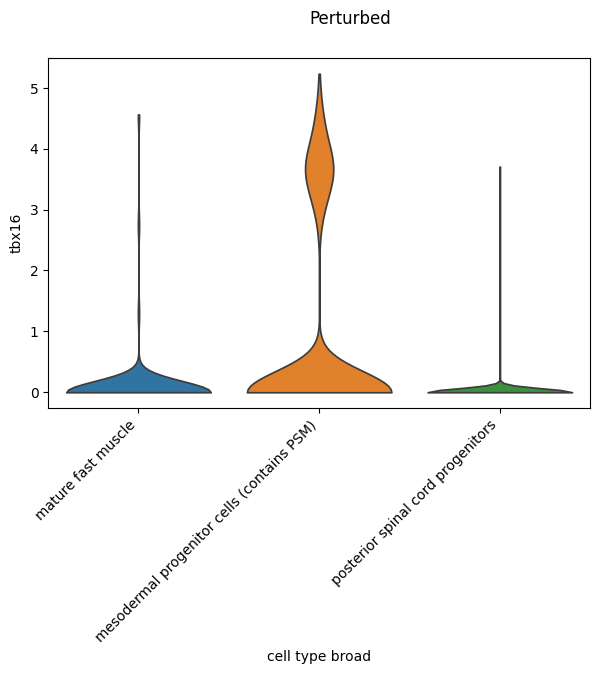

In [32]:
sc.pl.violin(adata_per, keys=keys[0], groupby="cell_type_broad", scale="width", stripplot=False, legend=False, show=False) 
fig = plt.gcf()  # Get the current figure
for ax in fig.axes:  # Iterate over all subplots
    plt.sca(ax)  # Set current axis
    plt.xticks(rotation=45, ha='right')  # Rotate labels
plt.suptitle("Perturbed")  # Add a title to the whole figure
plt.show()

In [ ]:
# targets = list(adata.obs['gene_target'].unique())
# hvg = adata.var['highly_variable']
# perturbed = adata.var['gene_short_name'].isin(targets)
# adata = adata[:,(hvg) | (perturbed)]
# print(adata.shape)

In [ ]:
# path = "/home/azweig/projects/zebrafish/data"
# suffix = "1k_hvg.h5ad"
# filename = os.path.join(path, suffix)
# adata = load_data(filename)

In [ ]:
gene_target = 'mafba'
adata = adata[(adata.obs['gene_target']=='ctrl-inj') | (adata.obs['gene_target']==gene_target)]
adata = adata[adata.obs['timepoint'] == 48]

print(adata.shape)

In [ ]:
print(sum(adata.obs['gene_target']=='ctrl-inj'))
print(sum(adata.obs['gene_target']==gene_target))

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [ ]:
sc.tl.pca(adata)

In [ ]:
sc.pp.neighbors(adata)

In [ ]:
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(
    adata,
    color="tissue",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [ ]:
sc.pl.umap(
    adata,
    color="gene_target",
    # Setting a smaller point size to get prevent overlap
    size=2,
)